# NIKHIL TEST

In [1]:
%load_ext autoreload
%autoreload 2

from neuralop.models import FNO

model = FNO(n_modes=(16, 16), hidden_channels=64,
                in_channels=1, out_channels=1)

In [2]:
print(model)

FNO(
  (positional_embedding): GridEmbeddingND()
  (fno_blocks): FNOBlocks(
    (convs): ModuleList(
      (0-3): 4 x SpectralConv(
        (weight): DenseTensor(shape=torch.Size([64, 64, 16, 9]), rank=None)
      )
    )
    (fno_skips): ModuleList(
      (0-3): 4 x Flattened1dConv(
        (conv): Conv1d(64, 64, kernel_size=(1,), stride=(1,), bias=False)
      )
    )
    (channel_mlp): ModuleList(
      (0-3): 4 x ChannelMLP(
        (fcs): ModuleList(
          (0): Conv1d(64, 32, kernel_size=(1,), stride=(1,))
          (1): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
        )
      )
    )
    (channel_mlp_skips): ModuleList(
      (0-3): 4 x SoftGating()
    )
  )
  (lifting): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(3, 128, kernel_size=(1,), stride=(1,))
      (1): Conv1d(128, 64, kernel_size=(1,), stride=(1,))
    )
  )
  (projection): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
      (1): Conv1d(128, 1, kernel_si

In [3]:
# model.save_checkpoint(save_folder='./TESTTEST/', save_name='example_fno')
# model = FNO.from_checkpoint(save_folder='./NIKHIL_SAFETYFUNC_TEST_checkpoints', save_name="model")
print(model)

FNO(
  (positional_embedding): GridEmbeddingND()
  (fno_blocks): FNOBlocks(
    (convs): ModuleList(
      (0-3): 4 x SpectralConv(
        (weight): DenseTensor(shape=torch.Size([64, 64, 16, 9]), rank=None)
      )
    )
    (fno_skips): ModuleList(
      (0-3): 4 x Flattened1dConv(
        (conv): Conv1d(64, 64, kernel_size=(1,), stride=(1,), bias=False)
      )
    )
    (channel_mlp): ModuleList(
      (0-3): 4 x ChannelMLP(
        (fcs): ModuleList(
          (0): Conv1d(64, 32, kernel_size=(1,), stride=(1,))
          (1): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
        )
      )
    )
    (channel_mlp_skips): ModuleList(
      (0-3): 4 x SoftGating()
    )
  )
  (lifting): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(3, 128, kernel_size=(1,), stride=(1,))
      (1): Conv1d(128, 64, kernel_size=(1,), stride=(1,))
    )
  )
  (projection): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
      (1): Conv1d(128, 1, kernel_si

### Plot darcy flow

Loading test db for resolution 16 with 50 samples 
Loading test db for resolution 32 with 50 samples 
16


/home/jingpei/Documents/arclab/neuraloperator/neuralop/data/datasets/pt_dataset.py:99: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(
/home/jingpei/Documen

Testing samples for res 16 have shape torch.Size([1, 16, 16])
32
Testing samples for res 32 have shape torch.Size([1, 32, 32])
Training samples have shape torch.Size([16, 16])


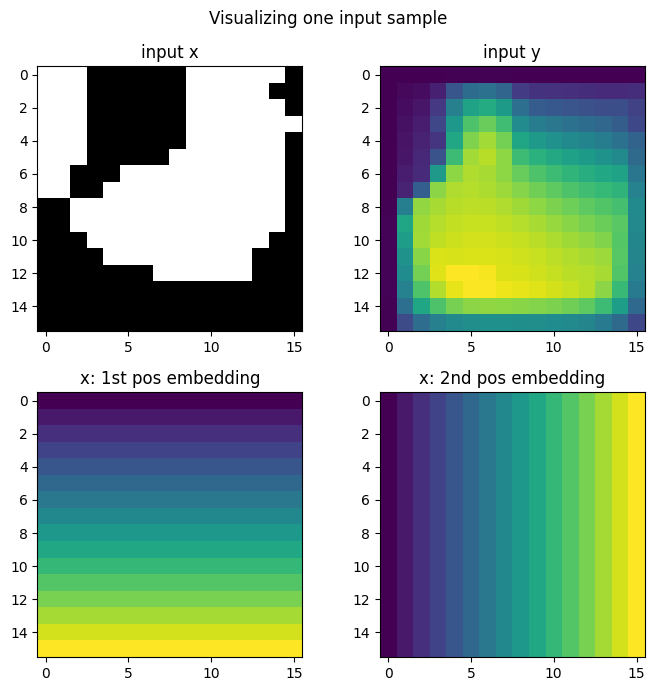

In [4]:
import matplotlib.pyplot as plt
from neuralop.data.datasets import load_darcy_flow_small
from neuralop.layers.embeddings import GridEmbedding2D

# %%
# Load the dataset
# ----------------
# Training samples are 16x16 and we load testing samples at both 
# 16x16 and 32x32 (to test resolution invariance).

train_loader, test_loaders, data_processor = load_darcy_flow_small(
        n_train=100, batch_size=4, 
        test_resolutions=[16, 32], n_tests=[50, 50], test_batch_sizes=[4, 2],
        )

train_dataset = train_loader.dataset

# %%
# Visualizing the data
# --------------------

for res, test_loader in test_loaders.items():
    print(res)
    # Get first batch
    batch = next(iter(test_loader))
    x = batch['x']
    y = batch['y']

    print(f'Testing samples for res {res} have shape {x.shape[1:]}')


data = train_dataset[0]
x = data['x']
y = data['y']

print(f'Training samples have shape {x.shape[1:]}')


# Which sample to view
index = 0

data = train_dataset[index]
data = data_processor.preprocess(data, batched=False)

# The first step of the default FNO model is a grid-based
# positional embedding. We will add it manually here to
# visualize the channels appended by this embedding.
positional_embedding = GridEmbedding2D(in_channels=1)
# at train time, data will be collated with a batch dim.
# we create a batch dim to pass into the embedding, then re-squeeze
x = positional_embedding(data['x'].unsqueeze(0)).squeeze(0)
y = data['y']
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(2, 2, 1)
ax.imshow(x[0], cmap='gray')
ax.set_title('input x')
ax = fig.add_subplot(2, 2, 2)
ax.imshow(y.squeeze())
ax.set_title('input y')
ax = fig.add_subplot(2, 2, 3)
ax.imshow(x[1])
ax.set_title('x: 1st pos embedding')
ax = fig.add_subplot(2, 2, 4)
ax.imshow(x[2])
ax.set_title('x: 2nd pos embedding')
fig.suptitle('Visualizing one input sample', y=0.98)
plt.tight_layout()
fig.show()

## Try to put through network

In [5]:
import torch
from neuralop.data.datasets import load_darcy_flow_small

train_loader, test_loaders, data_processor = load_darcy_flow_small(
     n_train=1000, batch_size=32,
     test_resolutions=[32], n_tests=[100],
     test_batch_sizes=[32],
)

for batch in train_loader:
    x_batch = batch['x']
    y_batch = batch['y']
    print("x:", x_batch.shape)
    print("hi")
    print("y:", y_batch.shape)
    break  # Remove this break if you want to print all batches

Loading test db for resolution 32 with 100 samples 
x: torch.Size([32, 1, 16, 16])
hi
y: torch.Size([32, 1, 16, 16])


In [6]:
preproc = data_processor.preprocess(batch)

In [7]:
print("x preproc: ", preproc['x'].shape)
print("y preproc: ", preproc['y'].shape)

x preproc:  torch.Size([32, 1, 16, 16])
y preproc:  torch.Size([32, 1, 16, 16])


In [8]:
diff_x = preproc['x'] - x_batch
diff_y = preproc['y'] - y_batch
print("Difference in x:", diff_x)
print("Difference in y:", diff_y)


Difference in x: tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0.,

In [9]:
sample = next(iter(train_loader))
x_batch = sample['x']
y_batch = sample['y']

preproc_sample = data_processor.preprocess(sample)

out = model(**preproc_sample)

print(out)

tensor([[[[-0.0545, -0.0546, -0.0548,  ..., -0.0528, -0.0523, -0.0649],
          [-0.0548, -0.0550, -0.0549,  ..., -0.0538, -0.0659, -0.0652],
          [-0.0555, -0.0554, -0.0552,  ..., -0.0543, -0.0538, -0.0657],
          ...,
          [-0.0712, -0.0714, -0.0713,  ..., -0.0684, -0.0678, -0.0672],
          [-0.0715, -0.0714, -0.0713,  ..., -0.0683, -0.0676, -0.0674],
          [-0.0720, -0.0724, -0.0716,  ..., -0.0684, -0.0681, -0.0679]]],


        [[[-0.0554, -0.0546, -0.0549,  ..., -0.0537, -0.0537, -0.0533],
          [-0.0555, -0.0551, -0.0554,  ..., -0.0539, -0.0536, -0.0537],
          [-0.0680, -0.0553, -0.0556,  ..., -0.0535, -0.0538, -0.0537],
          ...,
          [-0.0583, -0.0583, -0.0576,  ..., -0.0686, -0.0689, -0.0562],
          [-0.0586, -0.0581, -0.0581,  ..., -0.0570, -0.0574, -0.0567],
          [-0.0592, -0.0585, -0.0719,  ..., -0.0578, -0.0578, -0.0567]]],


        [[[-0.0556, -0.0548, -0.0550,  ..., -0.0666, -0.0665, -0.0660],
          [-0.0557, -0.055

## Theirs

In [10]:
# %%
# 
import torch
import matplotlib.pyplot as plt
import sys
from neuralop.models import FNO
from neuralop import Trainer
from neuralop.training import AdamW
from neuralop.data.datasets import load_darcy_flow_small
from neuralop.utils import count_model_params
from neuralop import LpLoss, H1Loss

device = 'cpu'


# %%
# Loading the Navier-Stokes dataset in 128x128 resolution
train_loader, test_loaders, data_processor = load_darcy_flow_small(
        n_train=1000, batch_size=32, 
        test_resolutions=[16, 32], n_tests=[100, 50],
        test_batch_sizes=[32, 32],
)


# %%
# We create an FNO model

model = FNO(n_modes=(16, 16),
             in_channels=1, 
             out_channels=1, 
             hidden_channels=32, 
             projection_channel_ratio=2, 
             factorization='tucker', 
             rank=0.42)

model = model.to(device)

n_params = count_model_params(model)
print(f'\nOur model has {n_params} parameters.')
sys.stdout.flush()


# %%
#Create the optimizer
optimizer = AdamW(model.parameters(), 
                                lr=8e-3, 
                                weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)


# %%
# Creating the losses
l2loss = LpLoss(d=2, p=2)
h1loss = H1Loss(d=2)

train_loss = h1loss
eval_losses={'h1': h1loss, 'l2': l2loss}


# %%


print('\n### MODEL ###\n', model)
print('\n### OPTIMIZER ###\n', optimizer)
print('\n### SCHEDULER ###\n', scheduler)
print('\n### LOSSES ###')
print(f'\n * Train: {train_loss}')
print(f'\n * Test: {eval_losses}')
sys.stdout.flush()


# %% 
# Create the trainer
trainer = Trainer(model=model, n_epochs=10,
                  device=device,
                  data_processor=data_processor,
                  wandb_log=False,
                  eval_interval=3,
                  use_distributed=False,
                  verbose=True)


# %%
# Actually train the model on our small Darcy-Flow dataset

trainer.train(train_loader=train_loader,
              test_loaders={},
              optimizer=optimizer,
              scheduler=scheduler, 
              regularizer=False, 
              training_loss=train_loss, 
              save_every=1,
              save_dir="./NIKHIL_TEST_checkpoints")



Loading test db for resolution 16 with 100 samples 
Loading test db for resolution 32 with 50 samples 

Our model has 520761 parameters.

### MODEL ###
 FNO(
  (positional_embedding): GridEmbeddingND()
  (fno_blocks): FNOBlocks(
    (convs): ModuleList(
      (0-3): 4 x SpectralConv(
        (weight): TuckerTensor(shape=(32, 32, 16, 9), rank=(26, 26, 13, 7))
      )
    )
    (fno_skips): ModuleList(
      (0-3): 4 x Flattened1dConv(
        (conv): Conv1d(32, 32, kernel_size=(1,), stride=(1,), bias=False)
      )
    )
    (channel_mlp): ModuleList(
      (0-3): 4 x ChannelMLP(
        (fcs): ModuleList(
          (0): Conv1d(32, 16, kernel_size=(1,), stride=(1,))
          (1): Conv1d(16, 32, kernel_size=(1,), stride=(1,))
        )
      )
    )
    (channel_mlp_skips): ModuleList(
      (0-3): 4 x SoftGating()
    )
  )
  (lifting): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(3, 64, kernel_size=(1,), stride=(1,))
      (1): Conv1d(64, 32, kernel_size=(1,), stride=(1,))
   

KeyboardInterrupt: 

In [ ]:
# .. resume_from_dir:
# resume training from saved checkpoint at epoch 10

trainer = Trainer(model=model, n_epochs=20,
                  device=device,
                  data_processor=data_processor,
                  wandb_log=False,
                  eval_interval=3,
                  use_distributed=False,
                  verbose=True)

trainer.train(train_loader=train_loader,
              test_loaders={},
              optimizer=optimizer,
              scheduler=scheduler, 
              regularizer=False, 
              training_loss=train_loss,
              resume_from_dir="./NIKHIL_TEST_checkpoints")

Trainer resuming from epoch 9
Training on 1000 samples
Testing on [] samples         on resolutions [].


[9] time=1.77, avg_loss=0.1731, train_err=5.4085
Eval: 
[12] time=1.69, avg_loss=0.1622, train_err=5.0679
Eval: 
[15] time=1.70, avg_loss=0.1468, train_err=4.5888
Eval: 
[18] time=1.71, avg_loss=0.1359, train_err=4.2460
Eval: 


{'train_err': 4.374346278607845,
 'avg_loss': 0.13997908091545105,
 'avg_lasso_loss': None,
 'epoch_train_time': 1.779949946794659}